In [38]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import math

df = pd.read_csv('training.csv')

In [39]:
x_train = df['YearsExperience'].values
y_train = df['Salary'].values

# Ordinary Least Squares Method



In [40]:

n = len(x_train)
def correlation(x, y): # find the correlation
    x_mean = sum(x)/n
    y_mean = sum(y)/n
    
    numerator = sum((x[i] - x_mean) * (y[i] - y_mean) for i in range(n))
    den = math.sqrt(sum((x[i]-x_mean)**2 for i in range(n)) *
                    sum((y[i]-y_mean)**2 for i in range(n)))

    return numerator/den

def slope(x, y): # find the slope using correlation and standard deviration
    return correlation(x,y) * (np.std(y,ddof = 1) / np.std(x, ddof = 1))

def intercept(x, y): # intercept = avg_y - slope * avg_x
    return sum(y)/n - slope(x,y)*sum(x)/n


def LR_line(x, y): # the regression line
    
    return f'y = {intercept(x,y)} + {slope(x,y)}*x'

# Gradient Descent method

In [41]:
def gradient_desent_method(x, y, learning_rate = 0.01, iterations = 1000):
    b0, b1 = 0, 0
    n = len(x)
    

    for _ in range(iterations):
       # predictions
        y_pred = b0 + b1 * x

        # errors
        error = y - y_pred

        # gradients
        db0 = -(1/n) * np.sum(error)
        db1 = -(1/n) * np.sum(x * error)

        # update
        b0 -= learning_rate * db0
        b1 -= learning_rate * db1
        
    # print(f'y = {b0} + {b1} * x')
    return b0 + b1 * x


## Result
Least squared      : y = 24848.204 + 9449.962 * x 


Gradient :  y = 21912.589 + 9880.814 * x

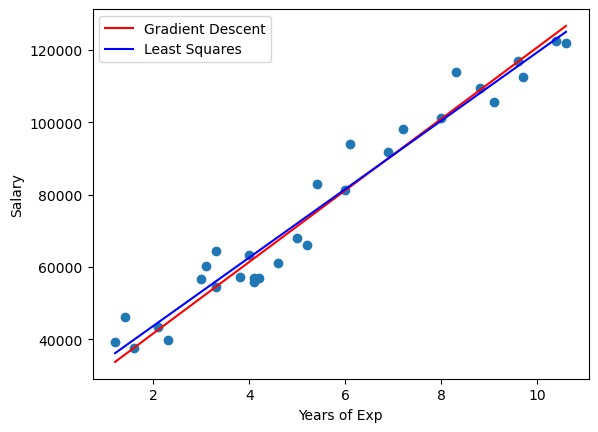

In [42]:
plt.plot(x_train, gradient_desent_method(x_train,y_train), color='red')
plt.plot(x_train, intercept(x_train,y_train) + slope(x_train,y_train)*x_train, color='blue')
plt.legend(['Gradient Descent', 'Least Squares'])
plt.scatter(x_train,y_train)
plt.xlabel("Years of Exp")
plt.ylabel("Salary")
plt.show()